In [ ]:
!pip -q install -U segmentation-models-pytorch==0.3.3 timm "albumentations>=1.4.0,<1.5.0" opencv-python

In [1]:
import os, random, glob, time
import numpy as np
import cv2
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

SEED = 42
def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True

seed_everything(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

/usr/local/lib/python3.12/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.24). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


Device: cuda


In [2]:
KVASIR_IMAGES_DIR = "/kaggle/input/datasets/debeshjha1/kvasirseg/Kvasir-SEG/Kvasir-SEG/images"
KVASIR_MASKS_DIR  = "/kaggle/input/datasets/debeshjha1/kvasirseg/Kvasir-SEG/Kvasir-SEG/masks"

CVC_ROOT = "/kaggle/input/datasets/balraj98/cvcclinicdb/PNG"
CVC_IMAGES_DIR = os.path.join(CVC_ROOT, "Original")
CVC_MASKS_DIR  = os.path.join(CVC_ROOT, "Ground Truth")

def list_image_mask_pairs(images_dir, masks_dir, img_exts=(".jpg",".jpeg",".png")):
    img_files = []
    for e in img_exts:
        img_files.extend(glob.glob(os.path.join(images_dir, f"*{e}")))
    img_files = sorted(img_files)
    
    mask_files = sorted(glob.glob(os.path.join(masks_dir, "*")))
    mask_map = {os.path.splitext(os.path.basename(m))[0]: m for m in mask_files}
    
    pairs = []
    for im in img_files:
        stem = os.path.splitext(os.path.basename(im))[0]
        if stem in mask_map:
            pairs.append((im, mask_map[stem]))
        else:
            for k in mask_map.keys():
                if k.startswith(stem) or stem.startswith(k):
                    pairs.append((im, mask_map[k]))
                    break
    return pairs

kvasir_pairs = list_image_mask_pairs(KVASIR_IMAGES_DIR, KVASIR_MASKS_DIR)
cvc_pairs = list_image_mask_pairs(CVC_IMAGES_DIR, CVC_MASKS_DIR)

print(f"Kvasir pairs mapped: {len(kvasir_pairs)}")
print(f"CVC pairs mapped: {len(cvc_pairs)}")

Kvasir pairs mapped: 1000
CVC pairs mapped: 612


In [3]:
def split_protocol_A(pairs, seed=SEED):
    idx = np.arange(len(pairs))
    rng = np.random.default_rng(seed)
    rng.shuffle(idx)
    
    test_idx = idx[:100]
    trainval_idx = idx[100:1000]
    
    trainval = [pairs[i] for i in trainval_idx]
    test = [pairs[i] for i in test_idx]
    
    rng2 = np.random.default_rng(seed + 1)
    tv_idx = np.arange(len(trainval))
    rng2.shuffle(tv_idx)
    
    val_idx = tv_idx[:100]
    train_idx = tv_idx[100:]
    
    return {
        "train": [trainval[i] for i in train_idx],
        "val": [trainval[i] for i in val_idx],
        "test": test
    }

splits = split_protocol_A(kvasir_pairs)
print(f"Train: {len(splits['train'])} | Val: {len(splits['val'])} | Test: {len(splits['test'])}")

Train: 800 | Val: 100 | Test: 100


In [4]:
IMG_SIZE = 384

train_tfms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5), 
    A.Affine(scale=(0.9, 1.1), translate_percent=(-0.05, 0.05), rotate=(-15, 15), p=0.5), 
    A.RandomBrightnessContrast(p=0.3),
    A.GaussNoise(p=0.2),
    A.Normalize(),
    ToTensorV2()
])

val_tfms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(),
    ToTensorV2()
])

class PolypSegDataset(Dataset):
    def __init__(self, pairs, transform=None):
        self.pairs = pairs
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, mask_path = self.pairs[idx]
        
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 127).astype(np.float32)

        if self.transform:
            aug = self.transform(image=img, mask=mask)
            img = aug["image"]
            mask = aug["mask"]

        mask = mask.unsqueeze(0)
        return img, mask

train_loader = DataLoader(PolypSegDataset(splits["train"], train_tfms), batch_size=8, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
val_loader = DataLoader(PolypSegDataset(splits["val"], val_tfms), batch_size=4, shuffle=False, num_workers=2, pin_memory=True)

kvasir_test_loader = DataLoader(PolypSegDataset(splits["test"], val_tfms), batch_size=1, shuffle=False, num_workers=2)
cvc_test_loader = DataLoader(PolypSegDataset(cvc_pairs, val_tfms), batch_size=1, shuffle=False, num_workers=2)

In [7]:
model = smp.Unet(
    encoder_name="mit_b2", 
    encoder_weights="imagenet", 
    in_channels=3, 
    classes=1, 
    activation=None
).to(device)

print(f"Architecture: UNet++ | Encoder: mit_b2 (SegFormer) | Params: {sum(p.numel() for p in model.parameters())/1e6:.2f}M")

Downloading: "https://github.com/qubvel/segmentation_models.pytorch/releases/download/v0.0.2/mit_b2.pth" to /root/.cache/torch/hub/checkpoints/mit_b2.pth


100%|██████████| 94.3M/94.3M [00:01<00:00, 92.0MB/s]


Architecture: UNet++ | Encoder: mit_b2 (SegFormer) | Params: 27.48M


In [8]:
focal_loss = smp.losses.FocalLoss(mode='binary')
dice_loss = smp.losses.DiceLoss(mode='binary')

def combo_loss(logits, targets, w_focal=0.5, w_dice=0.5):
    return w_focal * focal_loss(logits, targets) + w_dice * dice_loss(logits, targets)

def filter_noise_contours(mask01, min_area=50):
    """
    Threshold-based contour filter. Removes isolated noisy pixels < min_area.
    Preserves multiple legitimate polyps in a single frame.
    """
    mask = (mask01.astype(np.uint8) * 255)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    
    out = np.zeros_like(mask01)
    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] >= min_area:
            out[labels == i] = 1
    return out

@torch.no_grad()
def evaluate_metrics(logits, targets, thr=0.5, apply_pp=False, eps=1e-7):
    probs = torch.sigmoid(logits)
    preds = (probs > thr).float()

    if apply_pp:
        preds_pp = []
        for b in range(preds.size(0)):
            m = preds[b,0].detach().cpu().numpy().astype(np.uint8)
            m = filter_noise_contours(m, min_area=50)
            preds_pp.append(torch.from_numpy(m).to(preds.device).unsqueeze(0))
        preds = torch.stack(preds_pp, dim=0).float()

    preds = preds.view(preds.size(0), -1)
    targets = targets.view(targets.size(0), -1)

    inter = (preds * targets).sum(dim=1)
    union = preds.sum(dim=1) + targets.sum(dim=1)
    
    dice = (2.0 * inter + eps) / (union + eps)
    iou = (inter + eps) / (union - inter + eps)
    
    return dice.mean().item(), iou.mean().item()

In [9]:
EPOCHS = 40
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = torch.amp.GradScaler('cuda')

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    epoch_loss, epoch_dice, epoch_iou, n = 0, 0, 0, 0

    for imgs, masks in loader:
        imgs, masks = imgs.to(device, non_blocking=True), masks.to(device, non_blocking=True)
        
        with torch.set_grad_enabled(train):
            with torch.amp.autocast('cuda'):
                logits = model(imgs)
                loss = combo_loss(logits, masks)
            
            if train:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

        d, j = evaluate_metrics(logits.detach(), masks.detach())
        bs = imgs.size(0)
        epoch_loss += loss.item() * bs
        epoch_dice += d * bs
        epoch_iou += j * bs
        n += bs

    return epoch_loss / n, epoch_dice / n, epoch_iou / n

history = {"train_loss":[], "train_dice":[], "train_iou":[], "val_loss":[], "val_dice":[], "val_iou":[]}
best_dice = -1

print("Initiating Pipeline...")
for epoch in range(1, EPOCHS+1):
    t0 = time.time()
    tl, td, tj = run_epoch(train_loader, train=True)
    vl, vd, vj = run_epoch(val_loader, train=False)
    scheduler.step()
    
    for k, v in zip(history.keys(), [tl, td, tj, vl, vd, vj]):
        history[k].append(v)
        
    improved = vd > best_dice
    if improved:
        best_dice = vd
        torch.save(model.state_dict(), "best_model.pt")
        
    dt = time.time() - t0
    print(f"Ep {epoch:02d} | T: L={tl:.4f} D={td:.4f} I={tj:.4f} | V: L={vl:.4f} D={vd:.4f} I={vj:.4f} | {'BEST' if improved else ''} | {dt:.1f}s")

Initiating Pipeline...
Ep 01 | T: L=0.3198 D=0.5764 I=0.4679 | V: L=0.2308 D=0.7604 I=0.6547 | BEST | 57.5s
Ep 02 | T: L=0.2258 D=0.7325 I=0.6337 | V: L=0.1972 D=0.7935 I=0.6947 | BEST | 21.8s
Ep 03 | T: L=0.1897 D=0.7883 I=0.6988 | V: L=0.1324 D=0.8601 I=0.7757 | BEST | 22.2s
Ep 04 | T: L=0.1848 D=0.7882 I=0.6953 | V: L=0.1262 D=0.8615 I=0.7816 | BEST | 22.8s
Ep 05 | T: L=0.1624 D=0.8038 I=0.7194 | V: L=0.1266 D=0.8670 I=0.7948 | BEST | 23.7s
Ep 06 | T: L=0.1559 D=0.8078 I=0.7255 | V: L=0.1385 D=0.8413 I=0.7684 |  | 23.9s
Ep 07 | T: L=0.1409 D=0.8293 I=0.7497 | V: L=0.1088 D=0.8870 I=0.8256 | BEST | 23.5s
Ep 08 | T: L=0.1436 D=0.8320 I=0.7544 | V: L=0.1108 D=0.8755 I=0.8084 |  | 23.2s
Ep 09 | T: L=0.1256 D=0.8440 I=0.7717 | V: L=0.1039 D=0.8790 I=0.8146 |  | 23.5s
Ep 10 | T: L=0.1175 D=0.8500 I=0.7793 | V: L=0.1024 D=0.8822 I=0.8214 |  | 23.5s
Ep 11 | T: L=0.1193 D=0.8601 I=0.7882 | V: L=0.1075 D=0.8892 I=0.8241 | BEST | 23.5s
Ep 12 | T: L=0.1120 D=0.8636 I=0.7941 | V: L=0.1026 D=0.88

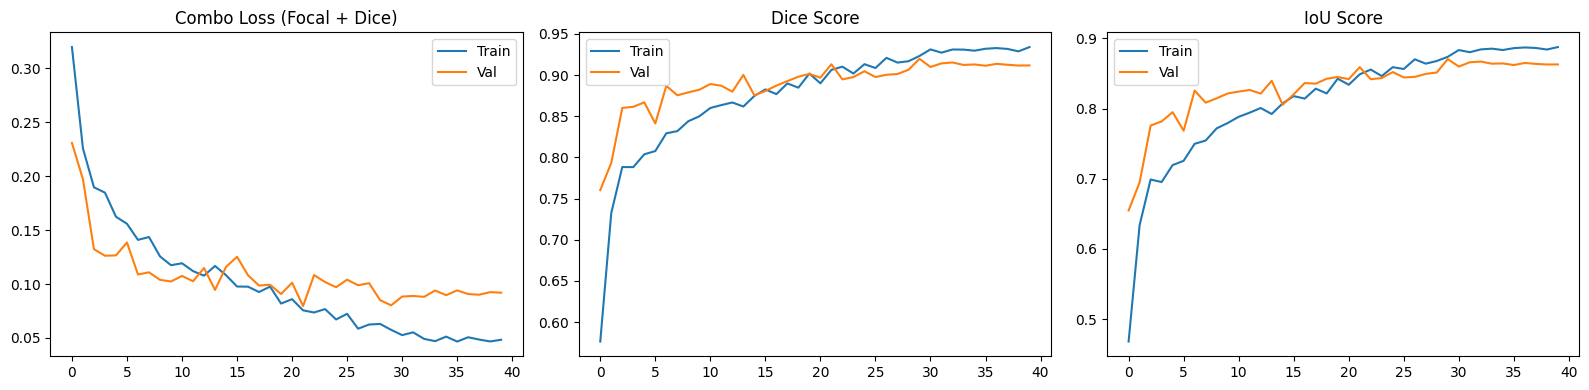

In [10]:
def plot_history(hist):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    
    axes[0].plot(hist["train_loss"], label="Train")
    axes[0].plot(hist["val_loss"], label="Val")
    axes[0].set_title("Combo Loss (Focal + Dice)"); axes[0].legend()
    
    axes[1].plot(hist["train_dice"], label="Train")
    axes[1].plot(hist["val_dice"], label="Val")
    axes[1].set_title("Dice Score"); axes[1].legend()
    
    axes[2].plot(hist["train_iou"], label="Train")
    axes[2].plot(hist["val_iou"], label="Val")
    axes[2].set_title("IoU Score"); axes[2].legend()
    
    plt.tight_layout()
    plt.show()

plot_history(history)

In [11]:
model.load_state_dict(torch.load("best_model.pt", weights_only=True))

def evaluate_dataset(loader, dataset_name):
    model.eval()
    raw_dices, raw_ious = [], []
    pp_dices, pp_ious = [], []
    
    with torch.no_grad():
        for imgs, masks in loader:
            imgs, masks = imgs.to(device), masks.to(device)
            with torch.amp.autocast('cuda'):
                logits = model(imgs)
            
            rd, rj = evaluate_metrics(logits, masks, apply_pp=False)
            pd, pj = evaluate_metrics(logits, masks, apply_pp=True)
            
            raw_dices.append(rd)
            raw_ious.append(rj)
            pp_dices.append(pd)
            pp_ious.append(pj)
            
    print(f"========== {dataset_name} ==========")
    print(f"RAW PREDICTIONS -> Dice: {np.mean(raw_dices):.4f} | IoU: {np.mean(raw_ious):.4f}")
    print(f"POST-PROCESSED  -> Dice: {np.mean(pp_dices):.4f} | IoU: {np.mean(pp_ious):.4f}\n")

evaluate_dataset(kvasir_test_loader, "Kvasir-SEG Test (Internal)")
evaluate_dataset(cvc_test_loader, "CVC-ClinicDB Test (External)")

========== Kvasir-SEG Test (Internal) ==========
RAW PREDICTIONS -> Dice: 0.8969 | IoU: 0.8345
POST-PROCESSED  -> Dice: 0.8969 | IoU: 0.8346

========== CVC-ClinicDB Test (External) ==========
RAW PREDICTIONS -> Dice: 0.8651 | IoU: 0.7933
POST-PROCESSED  -> Dice: 0.8651 | IoU: 0.7933

